In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Paths
PROJECT_ROOT = Path(os.getcwd()).parent 
DATA_DIR = PROJECT_ROOT / "data"
PHASE4_DIR = DATA_DIR / "phase4"
FIG_DIR = PROJECT_ROOT / "results" / "phase4" / "figures"
TAB_DIR = PROJECT_ROOT / "results" / "phase4" / "tables"

# Load precomputed outputs
bkm = pd.read_parquet(PHASE4_DIR / "bkm_moments.parquet")
premia = pd.read_parquet(PHASE4_DIR / "cumulant_premia.parquet")
decomp = pd.read_csv(TAB_DIR / "cyl_decomposition.csv")
theta_rob = pd.read_csv(PHASE4_DIR / "theta_robustness.csv")
moment_summary = pd.read_csv(TAB_DIR / "moment_summary.csv", header=[0, 1], index_col=0)

bkm["date"] = pd.to_datetime(bkm["date"])
premia["date"] = pd.to_datetime(premia["date"])

print(f"BKM moments: {len(bkm)} day-venue pairs")
print(f"  CME: {(bkm['venue']=='CME').sum()} days")
print(f"  DER: {(bkm['venue']=='DER').sum()} days")
print(f"Cumulant premia: {len(premia)} rows")
print(f"  Date range: {premia['date'].min().date()} -> {premia['date'].max().date()}")


BKM moments: 1946 day-venue pairs
  CME: 629 days
  DER: 1317 days
Cumulant premia: 1946 rows
  Date range: 2020-01-13 -> 2023-08-31


#### 1. Risk-Neutral Moment Summary

In [14]:
display(moment_summary)

# Matched-day cross-venue correlations
cme = bkm[bkm["venue"] == "CME"].set_index("date")
der = bkm[bkm["venue"] == "DER"].set_index("date")
matched = cme.join(der, lsuffix="_cme", rsuffix="_der", how="inner")
print(f"\nMatched CME-DER days: {len(matched)}")
for col in ["var_Q", "skew_Q", "kurt_Q"]:
    rho = matched[[f"{col}_cme", f"{col}_der"]].corr().iloc[0, 1]
    print(f"  Cross-venue correlation ({col}): rho = {rho:.3f}")


var_Q          skew_Q          kurt_Q            Pi_2            Pi_3  \
         mean     std    mean     std    mean     std    mean     std    mean   
venue                                                                           
CME    0.0498  0.0297 -1.0051  0.5152  9.3175  2.6795  0.0506  0.0308  0.0176   
DER    0.0552  0.0334 -1.0412  0.5085  9.2552  2.6300  0.0561  0.0347  0.0213   

                 Pi_4             vrp          
          std    mean     std    mean     std  
venue                                          
CME    0.0205  0.0295  0.0375  0.0119  0.0270  
DER    0.0255  0.0356  0.0461  0.0154  0.0307


Matched CME-DER days: 624
  Cross-venue correlation (var_Q): rho = 0.967
  Cross-venue correlation (skew_Q): rho = 0.849
  Cross-venue correlation (kurt_Q): rho = 0.795


#### 2. Risk-Neutral Moment Time Series

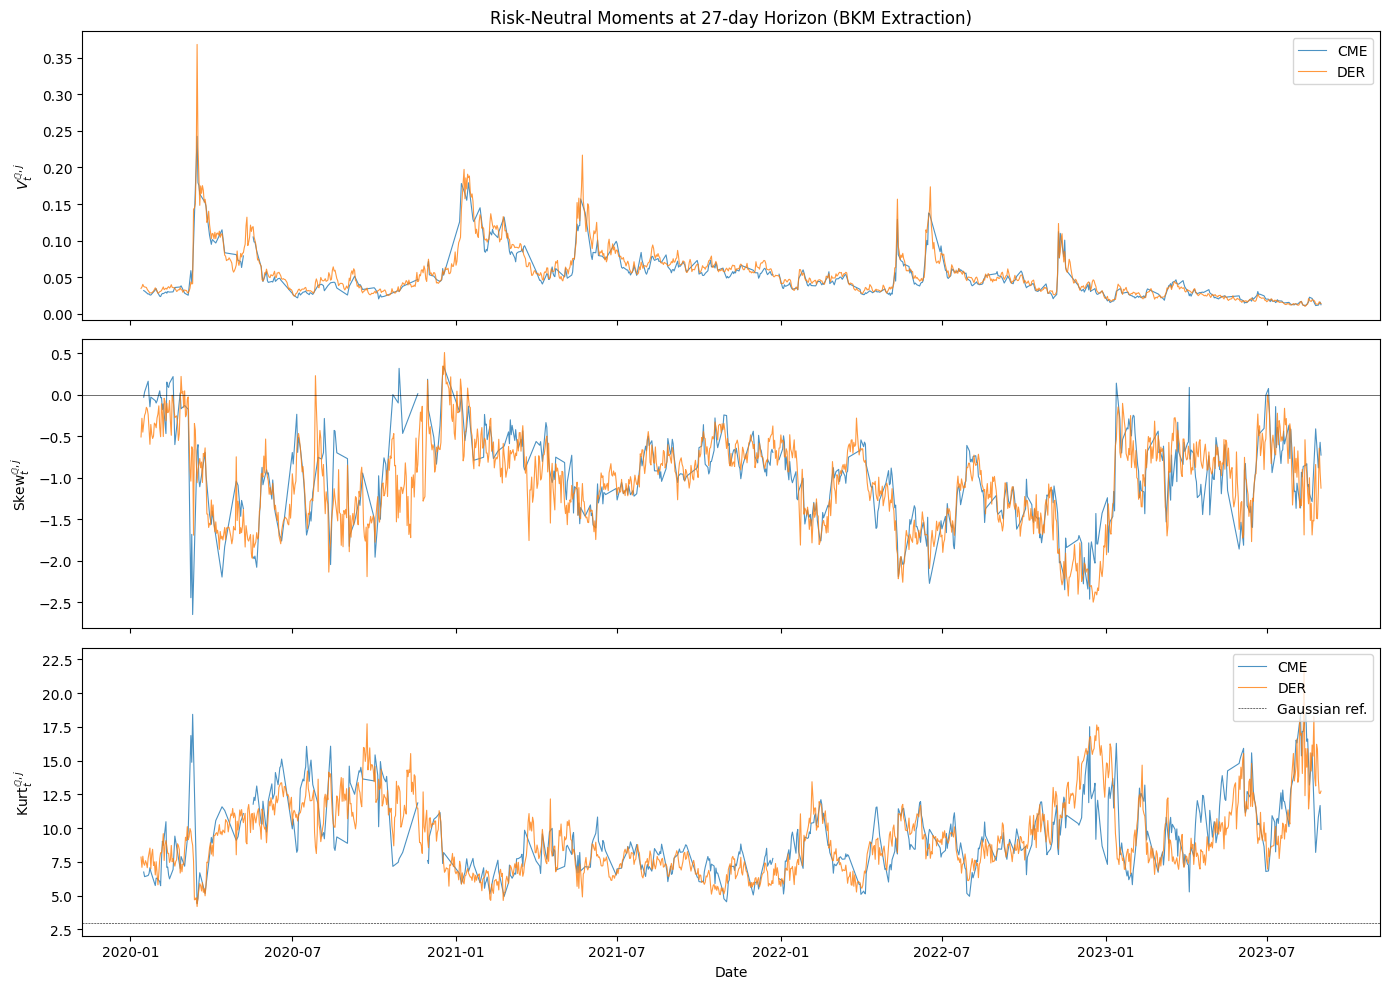

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for venue, color in [("CME", "C0"), ("DER", "C1")]:
    v = bkm[bkm["venue"] == venue].set_index("date").sort_index()
    axes[0].plot(v.index, v["var_Q"], color=color, lw=0.8, alpha=0.8, label=venue)
    axes[1].plot(v.index, v["skew_Q"], color=color, lw=0.8, alpha=0.8, label=venue)
    axes[2].plot(v.index, v["kurt_Q"], color=color, lw=0.8, alpha=0.8, label=venue)
axes[0].set_ylabel(r"$V_t^{\mathbb{Q},j}$")
axes[0].set_title("Risk-Neutral Moments at 27-day Horizon (BKM Extraction)")
axes[0].legend()
axes[1].set_ylabel(r"Skew$_t^{\mathbb{Q},j}$")
axes[1].axhline(0, color="black", lw=0.4)
axes[2].set_ylabel(r"Kurt$_t^{\mathbb{Q},j}$")
axes[2].axhline(3, color="black", lw=0.4, ls="--", label="Gaussian ref.")
axes[2].legend(loc="upper right")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()


#### 3. CL20 Lower-Bound Decomposition (Unconditional)

In [17]:
display(decomp.round(4))

print("\n=== Unconditional shares ===")
uncond = decomp[decomp["regime"] == "unconditional"]
for _, row in uncond.iterrows():
    print(f"  {row['venue']}: var {row['share_var']:.1%}, "
          f"skew {row['share_skew']:.1%}, kurt {row['share_kurt']:.1%} "
          f"| total 27d = {row['lb_total']:.4f} "
          f"(ann. {100*row['lb_total']*365/27:.0f}%)")


,venue,regime,n_days,Pi_2,Pi_3,Pi_4,lb_total,share_var,share_skew,share_kurt,mean_vrp
0,CME,unconditional,629,0.0506,0.0176,0.0295,0.0977,0.5177,0.1805,0.3017,0.0119
1,DER,unconditional,1317,0.0561,0.0213,0.0356,0.1129,0.4969,0.1882,0.3149,0.0154
2,CME,low,225,0.0257,0.0053,0.0074,0.0384,0.6694,0.1385,0.1922,-0.0033
3,CME,mid,195,0.0456,0.0144,0.0210,0.0809,0.5630,0.1778,0.2592,0.0070
4,CME,high,209,0.0824,0.0341,0.0615,0.1780,0.4629,0.1915,0.3456,0.0320
5,DER,low,257,0.0273,0.0062,0.0086,0.0421,0.6479,0.1479,0.2042,-0.0014
6,DER,mid,254,0.0485,0.0160,0.0234,0.0878,0.5519,0.1821,0.2659,0.0099
7,DER,high,254,0.0866,0.0371,0.0650,0.1887,0.4590,0.1964,0.3446,0.0367



=== Unconditional shares ===
  CME: var 51.8%, skew 18.1%, kurt 30.2% | total 27d = 0.0977 (ann. 132%)
  DER: var 49.7%, skew 18.8%, kurt 31.5% | total 27d = 0.1129 (ann. 153%)


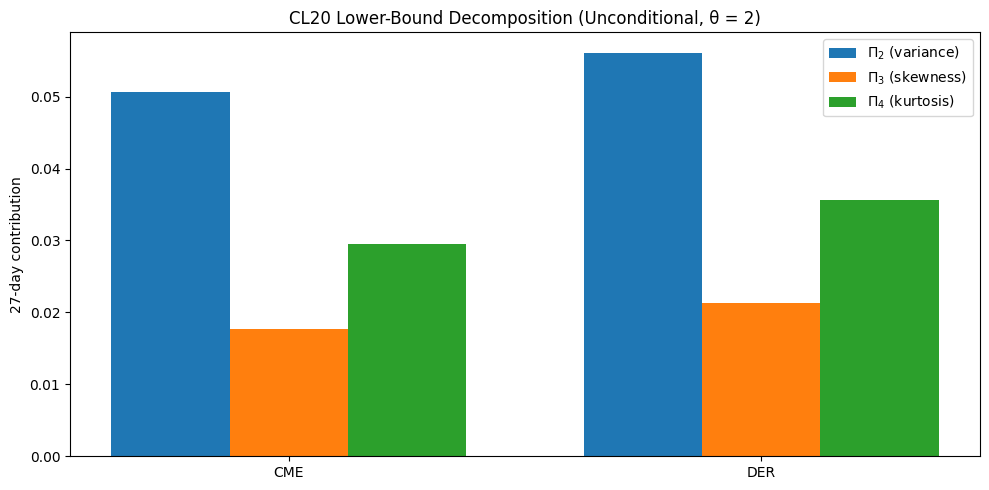

In [18]:
# Bar chart: unconditional lower-bound contributions
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(uncond)); width = 0.25
ax.bar(x - width, uncond["Pi_2"].values, width, label=r"$\Pi_2$ (variance)", color="C0")
ax.bar(x, uncond["Pi_3"].values, width, label=r"$\Pi_3$ (skewness)", color="C1")
ax.bar(x + width, uncond["Pi_4"].values, width, label=r"$\Pi_4$ (kurtosis)", color="C2")
ax.set_xticks(x); ax.set_xticklabels(uncond["venue"].values)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("27-day contribution")
ax.set_title("CL20 Lower-Bound Decomposition (Unconditional, θ = 2)")
ax.legend()
plt.tight_layout()
plt.show()


#### 4. CL24 Conditional Decomposition by Volatility Tercile

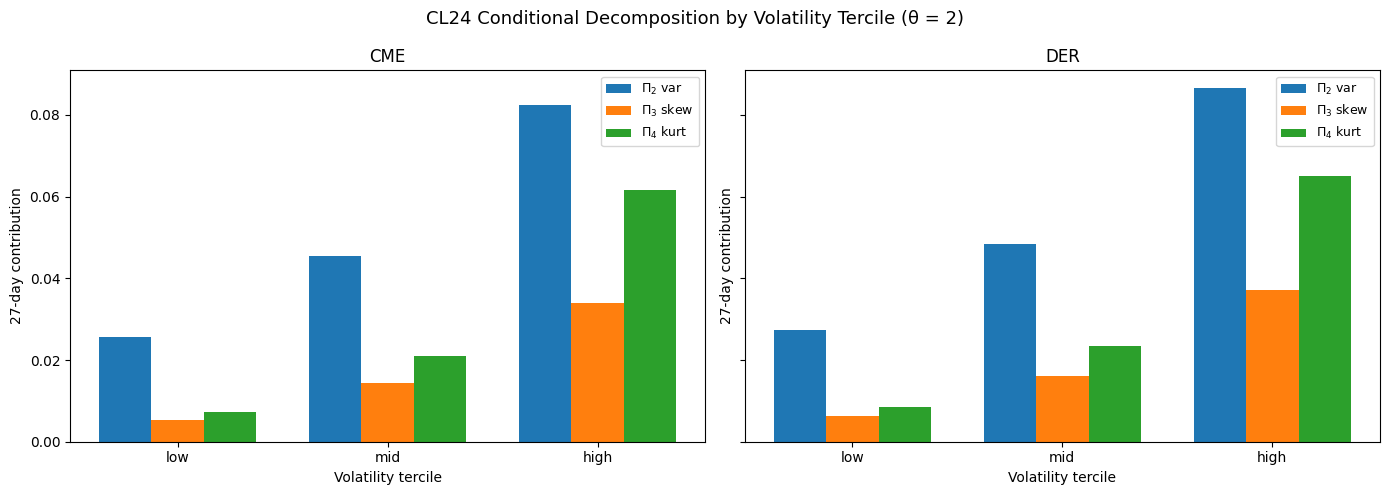

=== Moment shares by venue and tercile ===

  CME:
    low: var 66.9%, skew 13.8%, kurt 19.2% | total = 0.0384
    mid: var 56.3%, skew 17.8%, kurt 25.9% | total = 0.0809
    high: var 46.3%, skew 19.2%, kurt 34.6% | total = 0.1780

  DER:
    low: var 64.8%, skew 14.8%, kurt 20.4% | total = 0.0421
    mid: var 55.2%, skew 18.2%, kurt 26.6% | total = 0.0878
    high: var 45.9%, skew 19.6%, kurt 34.5% | total = 0.1887


In [19]:
# Tercile decomposition: stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, venue in zip(axes, ["CME", "DER"]):
    t_data = decomp[(decomp["venue"] == venue) & (decomp["regime"] != "unconditional")]
    terciles = ["low", "mid", "high"]
    x = np.arange(3)
    ax.bar(x, t_data.set_index("regime").loc[terciles, "Pi_2"].values,
           width=0.25, label=r"$\Pi_2$ var", color="C0")
    ax.bar(x + 0.25, t_data.set_index("regime").loc[terciles, "Pi_3"].values,
           width=0.25, label=r"$\Pi_3$ skew", color="C1")
    ax.bar(x + 0.5, t_data.set_index("regime").loc[terciles, "Pi_4"].values,
           width=0.25, label=r"$\Pi_4$ kurt", color="C2")
    ax.set_xticks(x + 0.25); ax.set_xticklabels(terciles)
    ax.set_title(venue); ax.legend(fontsize=9)
    ax.set_xlabel("Volatility tercile"); ax.set_ylabel("27-day contribution")
fig.suptitle("CL24 Conditional Decomposition by Volatility Tercile (θ = 2)", fontsize=13)
plt.tight_layout()
plt.show()

# Print shares by tercile
print("=== Moment shares by venue and tercile ===")
for venue in ["CME", "DER"]:
    print(f"\n  {venue}:")
    for regime in ["low", "mid", "high"]:
        row = decomp[(decomp["venue"] == venue) & (decomp["regime"] == regime)].iloc[0]
        print(f"    {regime}: var {row['share_var']:.1%}, skew {row['share_skew']:.1%}, "
              f"kurt {row['share_kurt']:.1%} | total = {row['lb_total']:.4f}")


#### 5. Cumulant Contribution Time Series and Boxplots

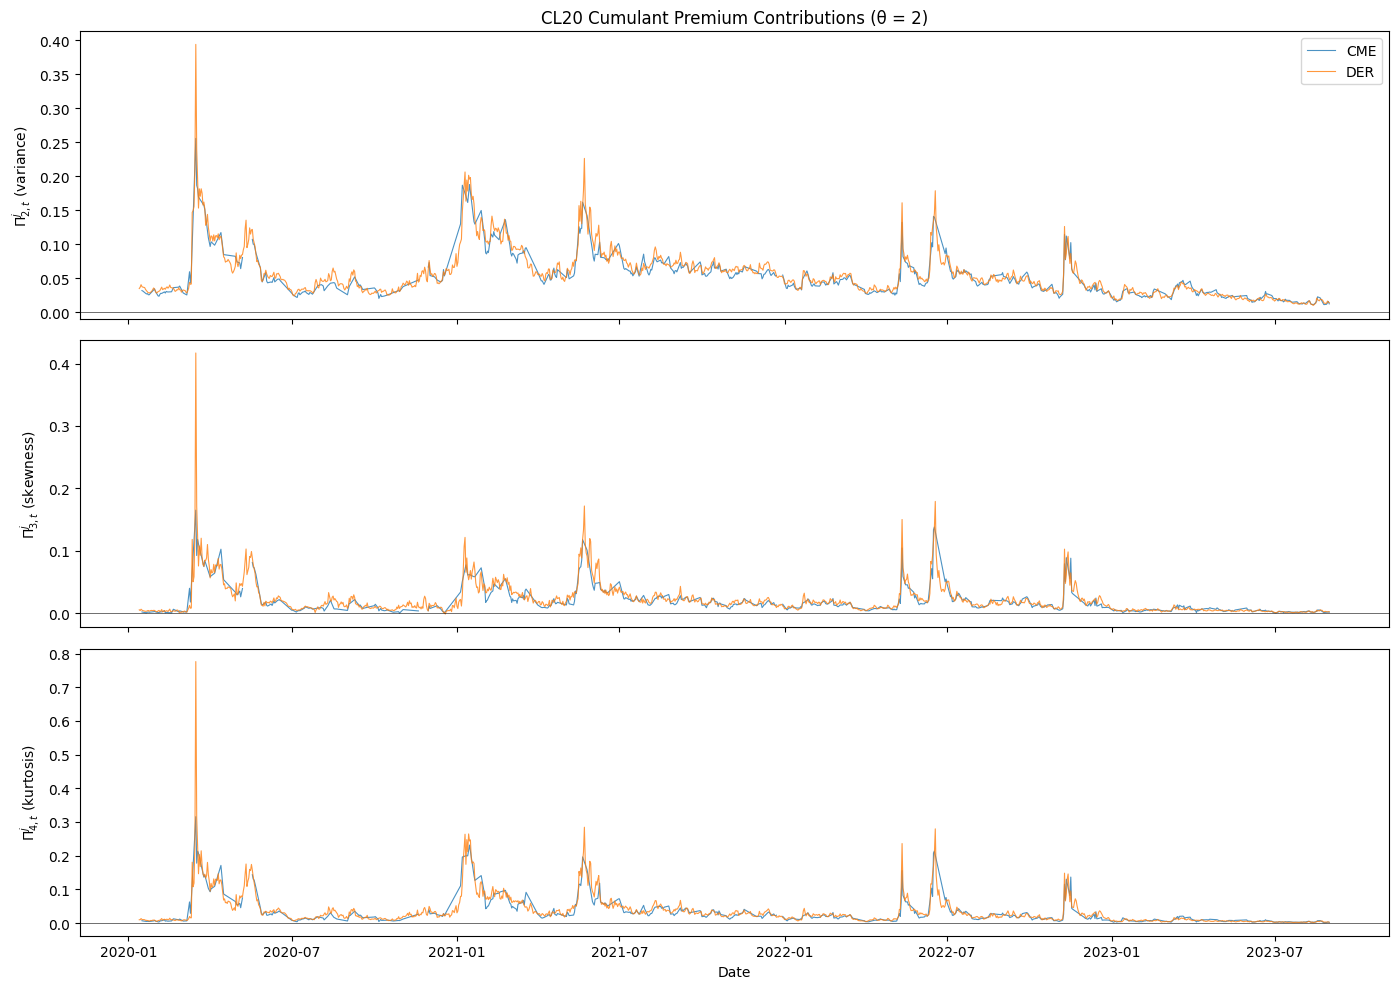

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for venue, color in [("CME", "C0"), ("DER", "C1")]:
    v = premia[premia["venue"] == venue].set_index("date").sort_index()
    axes[0].plot(v.index, v["Pi_2"], color=color, lw=0.8, alpha=0.8, label=venue)
    axes[1].plot(v.index, v["Pi_3"], color=color, lw=0.8, alpha=0.8, label=venue)
    axes[2].plot(v.index, v["Pi_4"], color=color, lw=0.8, alpha=0.8, label=venue)
for ax in axes:
    ax.axhline(0, color="black", lw=0.4)
axes[0].set_ylabel(r"$\Pi_{2,t}^j$ (variance)")
axes[0].set_title("CL20 Cumulant Premium Contributions (θ = 2)")
axes[0].legend()
axes[1].set_ylabel(r"$\Pi_{3,t}^j$ (skewness)")
axes[2].set_ylabel(r"$\Pi_{4,t}^j$ (kurtosis)")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()


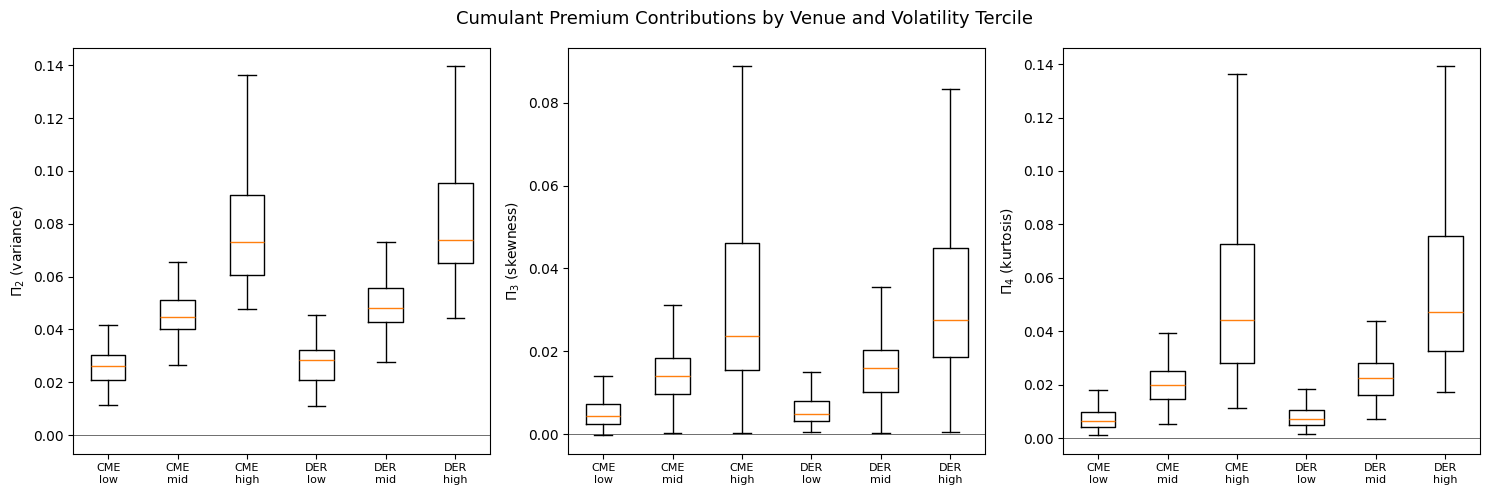

In [21]:
# Boxplots by venue x tercile
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, label) in zip(axes, [
    ("Pi_2", r"$\Pi_2$ (variance)"),
    ("Pi_3", r"$\Pi_3$ (skewness)"),
    ("Pi_4", r"$\Pi_4$ (kurtosis)")
]):
    data, labels_x = [], []
    for venue in ["CME", "DER"]:
        for tercile in ["low", "mid", "high"]:
            mask = (premia["venue"] == venue) & (premia["tercile"] == tercile)
            data.append(premia.loc[mask, col].dropna().values)
            labels_x.append(f"{venue}\n{tercile}")
    ax.boxplot(data, tick_labels=labels_x, showfliers=False)
    ax.axhline(0, color="black", lw=0.4)
    ax.set_ylabel(label); ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Cumulant Premium Contributions by Venue and Volatility Tercile", fontsize=13)
plt.tight_layout()
plt.show()


#### 6. Cross-Venue Moment Agreement and VRP Diagnostic

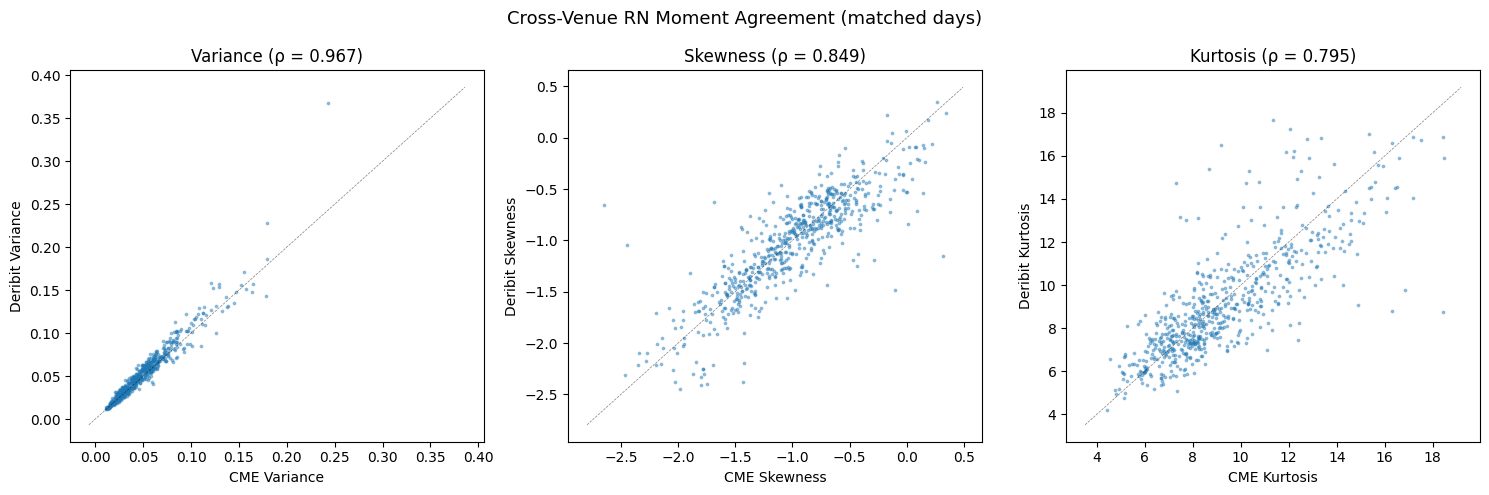

In [22]:
# Cross-venue scatter
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, label) in zip(axes, [
    ("var_Q", "Variance"), ("skew_Q", "Skewness"), ("kurt_Q", "Kurtosis")
]):
    ax.scatter(matched[f"{col}_cme"], matched[f"{col}_der"],
               s=3, alpha=0.4, color="C0")
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", lw=0.5, alpha=0.5)
    ax.set_xlabel(f"CME {label}"); ax.set_ylabel(f"Deribit {label}")
    rho = matched[[f"{col}_cme", f"{col}_der"]].corr().iloc[0, 1]
    ax.set_title(f"{label} (ρ = {rho:.3f})")
fig.suptitle("Cross-Venue RN Moment Agreement (matched days)", fontsize=13)
plt.tight_layout()
plt.show()


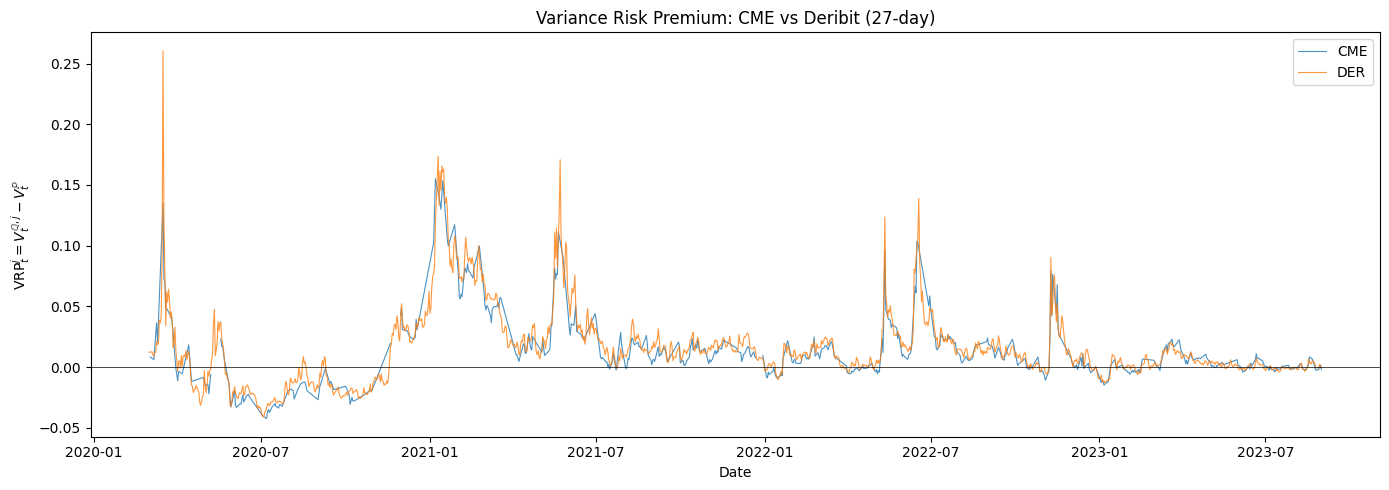

=== VRP Summary ===
  CME: mean = 0.0119, std = 0.0270, median = 0.0068, positive share = 71.0%
  DER: mean = 0.0154, std = 0.0307, median = 0.0103, positive share = 73.8%


In [23]:
# VRP time series
fig, ax = plt.subplots(figsize=(14, 5))
for venue, color in [("CME", "C0"), ("DER", "C1")]:
    v = premia[premia["venue"] == venue].set_index("date").sort_index()
    ax.plot(v.index, v["vrp"], color=color, lw=0.8, alpha=0.8, label=venue)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Date")
ax.set_ylabel(r"$\mathrm{VRP}_t^j = V_t^{\mathbb{Q},j} - V_t^{\mathbb{P}}$")
ax.set_title("Variance Risk Premium: CME vs Deribit (27-day)")
ax.legend()
plt.tight_layout()
plt.show()

print("=== VRP Summary ===")
for venue in ["CME", "DER"]:
    v = premia[premia["venue"] == venue]["vrp"].dropna()
    print(f"  {venue}: mean = {v.mean():.4f}, std = {v.std():.4f}, "
          f"median = {v.median():.4f}, positive share = {(v > 0).mean():.1%}")


#### 7. Preference Parameter Robustness ($\theta$ sweep)

=== Theta Robustness Sweep ===



,venue,theta,lambda_1,lambda_2,lambda_3,mean_Pi_2,mean_Pi_3,mean_Pi_4,mean_lb_total,lb_annualized_pct
0,CME,1.0,1.0,-0.6667,0.5000,0.0506,0.0118,0.0147,0.0771,104.2313
1,DER,1.0,1.0,-0.6667,0.5000,0.0561,0.0142,0.0178,0.0881,119.0639
2,CME,2.0,1.0,-1.0000,1.0000,0.0506,0.0176,0.0295,0.0977,132.1128
3,DER,2.0,1.0,-1.0000,1.0000,0.0561,0.0213,0.0356,0.1129,152.6810
4,CME,3.0,1.0,-1.3333,1.6667,0.0506,0.0235,0.0491,0.1233,166.6384
5,DER,3.0,1.0,-1.3333,1.6667,0.0561,0.0283,0.0593,0.1437,194.3105


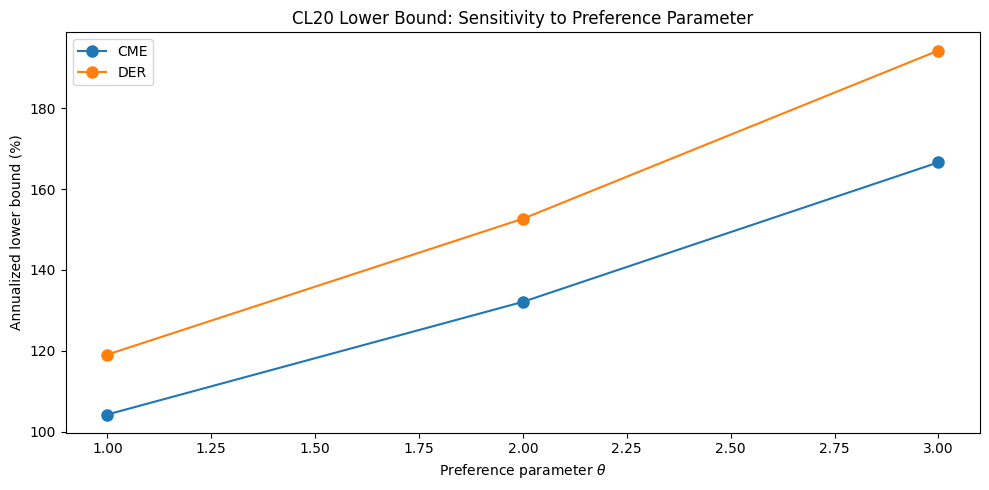

In [24]:
print("=== Theta Robustness Sweep ===\n")
display(theta_rob.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
for venue, color in [("CME", "C0"), ("DER", "C1")]:
    v = theta_rob[theta_rob["venue"] == venue].sort_values("theta")
    ax.plot(v["theta"], v["lb_annualized_pct"], "o-", color=color, label=venue, markersize=8)
ax.set_xlabel(r"Preference parameter $\theta$")
ax.set_ylabel("Annualized lower bound (%)")
ax.set_title("CL20 Lower Bound: Sensitivity to Preference Parameter")
ax.legend()
plt.tight_layout()
plt.show()


 ## Summary



 **Key findings (Phase 4, common window, $\theta = 2$):**



 1. **Kurtosis is co-equal with variance** in the CL20 lower bound (~30% vs ~52%

    unconditionally), distinguishing Bitcoin from the variance-dominated equity premium.



 2. **Composition shift across regimes**: variance share drops from ~67% (low-vol)

    to ~46% (high-vol) while kurtosis share rises from ~19% to ~35%, indicating

    that tail risk pricing intensifies under stress.



 3. **Cross-venue consistency**: Deribit exceeds CME at every moment order, but the

    *shares* are nearly identical (within 2 pp), indicating the MFK tent-shape

    operates uniformly across moment orders.



 4. **VRP diagnostic**: positive on both venues (CME 1.2%, DER 1.5% per 27 days),

    confirming the risk-neutral variance exceeds the physical variance.



 5. **Theta robustness**: the cross-venue ordering and composition shift are

    invariant to the preference parameter.